In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from os.path import join
import sys
sys.path.append(join(".", ".."))
from utils import *

In [8]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
})

In [9]:
data = np.load("../resource_analysis_data/fig2_data.npz")

dimensions = data["dimensions"]
error_tols = data["error_tols"]

# Bell basis
bell_basis_trotter_steps = data["bell_basis_trotter_steps"]
bell_basis_single_qubit_gates = data["bell_basis_single_qubit_gates"]
bell_basis_two_qubit_gates = data["bell_basis_two_qubit_gates"]
bell_basis_gate_count = bell_basis_trotter_steps * (bell_basis_single_qubit_gates + bell_basis_two_qubit_gates)

# One-hot
one_hot_trotter_steps = data["one_hot_trotter_steps"]
one_hot_single_qubit_gates = data["one_hot_single_qubit_gates"]
one_hot_two_qubit_gates = data["one_hot_two_qubit_gates"]
one_hot_gate_count = one_hot_trotter_steps * (one_hot_single_qubit_gates + one_hot_two_qubit_gates)


In [10]:
def log_tick_formatter(val, pos=None):
    return f"$10^{{{int(val)}}}$"  # remove int() if you don't use MaxNLocator
    # return f"{10**val:.2e}"      # e-Notation

<Figure size 640x480 with 0 Axes>

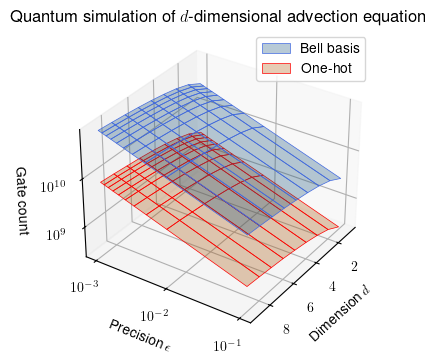

In [14]:

plt.clf()

ax = plt.figure(figsize=(10, 4)).add_subplot(projection='3d')

X, Y = np.meshgrid(dimensions, np.log10(error_tols), indexing='ij')
# Plot the 3D surface
ax.plot_surface(X, Y, np.log10(bell_basis_gate_count), edgecolor='royalblue', lw=0.5, rstride=1, cstride=1,
                alpha=0.3, label="Bell basis")
ax.plot_surface(X, Y, np.log10(one_hot_gate_count), edgecolor='red', lw=0.5, rstride=1, cstride=1,
                alpha=0.3, label="One-hot")
ax.view_init(elev=32, azim=34, roll=0)

ax.set_xlabel(rf"Dimension $d$")
ax.set_ylabel(rf"Precision $\epsilon$")
ax.set_zlabel("Gate count")

ax.zaxis.set_major_formatter(mticker.FuncFormatter(log_tick_formatter))
ax.zaxis.set_major_locator(mticker.MaxNLocator(integer=True))


ax.yaxis.set_major_formatter(mticker.FuncFormatter(log_tick_formatter))
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
# ax.zaxis._set_scale('log')
ax.legend()
plt.title("Quantum simulation of $d$-dimensional advection equation")
plt.savefig(join("..", "..", "figures", "Fig_2.pdf"), bbox_inches='tight')
plt.show()